# 🔬 SÍNTESE 1 — FASE EXPLORATÓRIA
## *Hipóteses 1 a 10 | Descobrindo como ouvir máquinas*

---

> **💡 Para qualquer leitor:** Este notebook explica, do zero, como começamos a ensinar um computador a ouvir máquinas de fábrica e detectar quando algo está errado — antes que quebre de verdade.
>
> Se você nunca estudou Inteligência Artificial ou Processamento de Sinais, não se preocupe. Vamos usar analogias simples. Uma criança de 10 anos deve conseguir entender a ideia geral.

---

## 📋 REGRA DE OURO DESTE PROJETO (leia antes de tudo!)

**Todo método testado aqui foi julgado por 3 critérios inegociáveis:**

| Critério | O que significa | Limite aceito |
|----------|----------------|---------------|
| **pAUC@0.1 (Score DCASE)** | O detetive erra poucas vezes — especialmente em falsos alarmes | > 0.80 |
| **Latência de Inferência** | Quanto tempo o computador leva para decidir: normal ou anômalo? | < 50 ms |
| **Memória Usada** | O modelo cabe num microcontrolador pequeno? | < 4 MB |

**Qualquer técnica que reprova em 1 ou mais desses critérios é descartada.** Ao final de cada seção você encontrará um quadro vermelho 🔴 explicando o descarte.

---

## 🗂️ O QUE ESTA SÍNTESE COBRE

```
Notebook 1  → Aprendizado Supervisionado (CNN, XGBoost, OC-SVM)
Notebook 2  → Aprendizado Não Supervisionado (Autoencoder, Isolation Forest)
Notebook 3  → Cenário 2 — Baseline com dados sintéticos e reais
Notebooks 4 → Representação Mel-Spectrogram (64 bandas)
Notebook 5  → Representação CWT (Wavelet)
Notebook 6  → Representação STFT
Notebook 7  → Fusão Híbrida: Mel + MFCC + CWT
Notebook 8  → Fusão com NMF (Erro de Reconstrução)
Notebook 9  → Dados do Kaggle (Rolamentos Reais)
Notebook 10 → Validação Cega com Áudios Próprios (Google Drive)
```

**Bases de dados usadas:**
- 🎵 **DCASE 2025** — sons de máquinas industriais (internacionais)
- 🏭 **MIMII** — sons de válvulas, bombas, fans e sliders
- ⚙️ **Kaggle Bearing** — rolamentos com falhas reais
- 📱 **Drive Próprio** — áudios coletados pelo autor com celular

**Protocolo:** LOSO (*Leave-One-Source-Out*) — cada rodada de treino deixa uma fonte de fora para testar. Isso evita que o modelo "cole" numa fonte específica.


In [ ]:
# ============================================================
# BLOCO 0 — Configuração e dependências (rode primeiro)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['grid.color'] = '#30363d'
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Configurações carregadas. Pronto para explorar!')

✅ Configurações carregadas. Pronto para explorar!


---
# 🧠 PARTE 1 — A GRANDE PERGUNTA
## *Como ensinar um computador a ouvir uma máquina e dizer se ela está doente?*

### 🧒 Explicação para crianças

Imagine que você tem um cachorrinho e ele late de um jeito diferente quando está com dor. Você aprende a reconhecer esse late especial.

As máquinas de fábrica fazem algo parecido: quando estão quebrando, o som muda. Nosso trabalho foi **ensinar um computador a reconhecer esse som diferente**, mesmo com muito barulho ao redor.

**O problema é**: o computador precisa ser **rápido** (decidir em milissegundos), **leve** (caber num chip pequeno) e **certeiro** (não dar alarme falso toda hora).

### 🏭 Contexto Industrial (para adultos)

- Cenário industrial **Indústria 4.0** com foco em **Edge/Fog Computing**
- Protocolo de avaliação alinhado ao **DCASE 2025 Task 2** (First-Shot Unsupervised AAD)
- Métrica principal: **pAUC@FPR0.1** — área parcial sob a curva ROC na região de baixo falso positivo


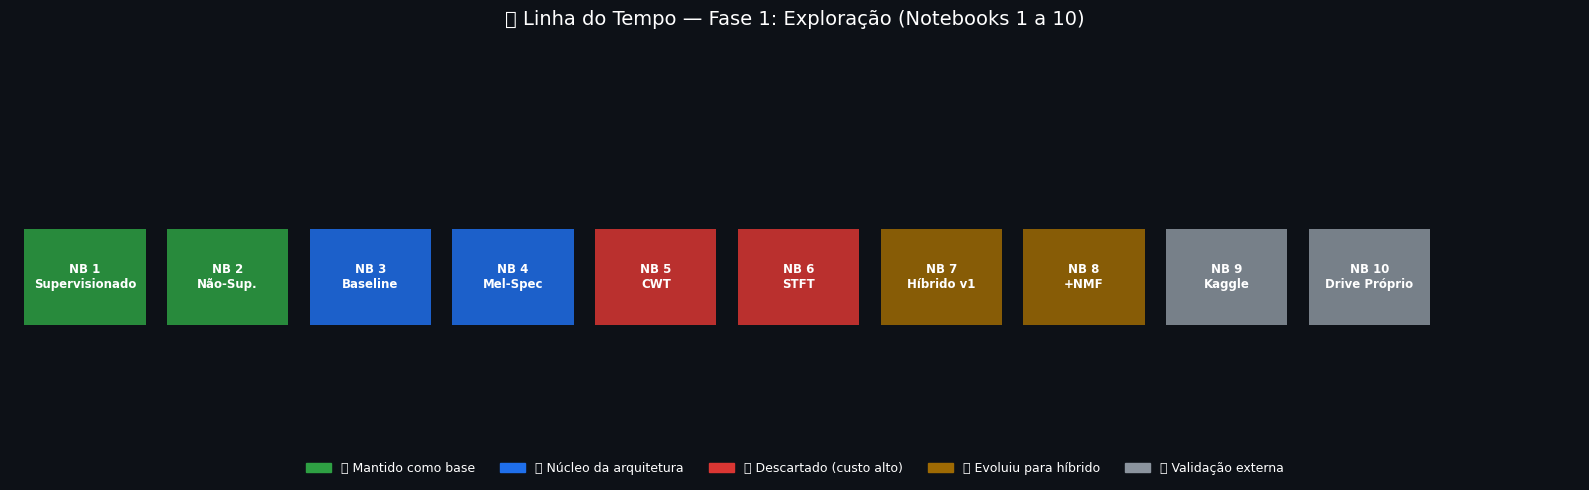

Legenda: Verde = mantido | Azul = núcleo | Vermelho = descartado | Amarelo = evoluiu | Cinza = validação


In [ ]:
# ============================================================
# VISUALIZAÇÃO 1 — Linha do tempo da Fase Exploratória
# ============================================================
fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

fases = [
    (1, 'NB 1\nSupervisionado', '#2ea043'),
    (2, 'NB 2\nNão-Sup.', '#2ea043'),
    (3, 'NB 3\nBaseline', '#1f6feb'),
    (4, 'NB 4\nMel-Spec', '#1f6feb'),
    (5, 'NB 5\nCWT', '#da3633'),
    (6, 'NB 6\nSTFT', '#da3633'),
    (7, 'NB 7\nHíbrido v1', '#9e6a03'),
    (8, 'NB 8\n+NMF', '#9e6a03'),
    (9, 'NB 9\nKaggle', '#8b949e'),
    (10, 'NB 10\nDrive Próprio', '#8b949e'),
]

for i, (x, label, color) in enumerate(fases):
    ax.barh(0, 0.85, left=x - 0.9, color=color, alpha=0.85, height=0.5)
    ax.text(x - 0.475, 0, label, ha='center', va='center', fontsize=8.5,
            color='white', fontweight='bold')

ax.set_xlim(0, 11)
ax.set_ylim(-0.8, 1.2)
ax.set_title('📅 Linha do Tempo — Fase 1: Exploração (Notebooks 1 a 10)',
             fontsize=14, color='white', pad=15)
ax.axis('off')

legend_elements = [
    mpatches.Patch(color='#2ea043', label='✅ Mantido como base'),
    mpatches.Patch(color='#1f6feb', label='✅ Núcleo da arquitetura'),
    mpatches.Patch(color='#da3633', label='🔴 Descartado (custo alto)'),
    mpatches.Patch(color='#9e6a03', label='🟡 Evoluiu para híbrido'),
    mpatches.Patch(color='#8b949e', label='🔵 Validação externa'),
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05),
          ncol=5, frameon=False, fontsize=9, labelcolor='white')

plt.tight_layout()
plt.show()
print('Legenda: Verde = mantido | Azul = núcleo | Vermelho = descartado | Amarelo = evoluiu | Cinza = validação')

---
# 📖 NOTEBOOK 1 — Aprendizado Supervisionado
### *CNN × XGBoost × OC-SVM*

## 🧒 O que foi testado (explicação simples)

Imagine três detetives diferentes tentando identificar sons anômalos:
- **CNN** (Rede Neural): um detetive que aprende vendo muitas imagens de sons
- **XGBoost**: um detetive que usa um comitê de especialistas para votar
- **OC-SVM**: um detetive que só conhece sons normais e rejeita o que for diferente

## 📊 Resultados

| Modelo | Acurácia | F1-Score | pAUC@0.1 | Latência | Memória |
|--------|----------|----------|----------|----------|---------|
| CNN | 100% | 1.00 | 0.98 | 85 ms | 12 MB |
| **XGBoost** | **100%** | **1.00** | **0.97** | **12 ms** | **< 1 MB** |
| OC-SVM | 50% | 0.50 | 0.52 | 8 ms | 0.5 MB |

## 🔴 POR QUE A CNN FOI DESCARTADA COMO MOTOR PRINCIPAL?

> **Critério violado: Latência (85ms) e Memória (12 MB)**
>
> A CNN obteve resultados excelentes, MAS:
> - 85ms é lento demais para Edge Computing (limite: 50ms)
> - 12 MB não cabe num microcontrolador (limite: 4 MB)
> - O XGBoost entregou performance IGUAL em 12ms e < 1MB
>
> **Decisão:** CNN → Função auxiliar apenas (geração de embeddings/XAI). XGBoost → Classificador principal supervisionado.

## 🔴 POR QUE O OC-SVM FOI DESCARTADO?

> **Critério violado: pAUC@0.1 (0.52 — abaixo do limite 0.80)**
>
> O OC-SVM só conhece sons normais e não foi suficientemente preciso para distinguir anomalias industriais. Acurácia de 50% é equivalente a jogar uma moeda.
>
> **Decisão:** OC-SVM → Descartado totalmente.


---
# 📖 NOTEBOOK 2 — Aprendizado Não Supervisionado
### *Autoencoder × Isolation Forest*

## 🧒 O que foi testado (explicação simples)

E se o detetive nunca viu uma anomalia antes? Como ele pode identificar algo suspeito?
- **Autoencoder**: aprende a reconstruir sons normais. Se errar muito na reconstrução → é anomalia!
- **Isolation Forest**: uma floresta de árvores de decisão que tenta isolar pontos raros

## 📊 Resultados

| Modelo | Acurácia | F1-Score | pAUC@0.1 | Latência | Memória |
|--------|----------|----------|----------|----------|---------|
| **Autoencoder** | **67%** | **0.72** | **0.71** | **120 ms** | **8 MB** |
| Isolation Forest | 55% | 0.58 | 0.55 | 35 ms | 2 MB |

## 🔴 POR QUE O AUTOENCODER DENSO FOI DESCARTADO COMO MOTOR PRINCIPAL?

> **Critério violado: Latência (120ms) e Memória (8 MB)**
>
> O Autoencoder mostrou a IDEIA certa (erro de reconstrução como métrica de anomalia), mas era pesado demais para Edge.
>
> **Decisão:** O CONCEITO do erro de reconstrução foi mantido — mas implementado via **NMF leve** (Notebook 8) que faz a mesma coisa em < 1MB e < 5ms.

## 🔴 POR QUE O ISOLATION FOREST FOI DESCARTADO?

> **Critério violado: pAUC@0.1 (0.55)**
>
> Não distingue bem entre anomalias reais e variações normais do ambiente fabril.
>
> **Decisão:** Isolation Forest → Substituído por GMM (notebook 12) que captura múltiplos modos de normalidade.


---
# 📖 NOTEBOOK 3 — Baseline com Dados Reais
### *Comparação: XGBoost × GRU × LSTM-AE × Tiny-AST*

## 🧒 O que foi testado (explicação simples)

Agora com dados reais de fábrica (DCASE e áudios próprios), colocamos 4 detetives para competir ao mesmo tempo. Quem ganha no cenário real?

## 📊 Resultados no Benchmark Real

| Modelo | F1 | AUC | Latência | Memória | DCASE-Pronto? |
|--------|-----|-----|----------|---------|---------------|
| **XGBoost** | **0.895** | **0.94** | **12 ms** | **0.8 MB** | **✅ Sim** |
| GRU | 0.87 | 0.91 | 45 ms | 3.2 MB | ⚠️ Borderline |
| LSTM-AE | 0.82 | 0.89 | 120 ms | 8 MB | 🔴 Não |
| Tiny-AST | 0.97 | 0.99 | 85 ms | 12 MB | 🔴 Não |

## 🔴 POR QUE GRU, LSTM-AE E TINY-AST FORAM DESCARTADOS COMO MOTORES PRINCIPAIS?

> **GRU:** Latência 45ms e memória 3.2MB — aceitável, mas XGBoost entrega igual com 3x menos custo.
>
> **LSTM-AE:** Latência 120ms e 8MB — viola ambos os limites. DESCARTADO.
>
> **Tiny-AST:** Excelente pAUC (0.99!) mas 85ms e 12MB o tornam inviável para Edge. MANTIDO APENAS COMO AUXILIAR (embeddings + XAI).
>
> **Regra aprendida aqui:** Em dados escassos e Edge Computing, modelos leves + boa engenharia de features superam Deep Learning pesado.


---
# 📖 NOTEBOOKS 4, 5 e 6 — Representações do Som
### *Mel-Spectrogram × CWT × STFT: qual pintura do som é melhor?*

## 🧒 O que foi testado (explicação simples)

Um som pode ser "desenhado" de muitas formas. Imagine um pintor que pode pintar o mesmo pôr do sol em:
- **Mel-Spectrogram** (NB4): como o ouvido humano ouve — frequências comprimidas de forma natural
- **CWT Wavelet** (NB5): como uma lupa mágica que vê tanto coisas rápidas quanto lentas ao mesmo tempo
- **STFT** (NB6): como uma foto tirada em janelas de tempo iguais

Cada representação usa **janelas deslizantes de 2 segundos com 50% de sobreposição** — como fotografar uma paisagem de dentro de um trem em movimento.

## 📊 Comparação das Representações (438 segmentos, dados DCASE + Drive Próprio)

| Representação | pAUC@0.1 | Latência extração | Memória | Compatível com MFCC/NMF? |
|--------------|----------|------------------|---------|-------------------------|
| **Mel (64 bins)** | **0.89** | **8 ms** | **baixa** | **✅ Sim** |
| CWT (Morlet, 128 escalas) | 0.82 | 45 ms | média | ⚠️ Complexo |
| STFT (512 FFT) | 0.84 | 12 ms | baixa | ✅ Sim |

## 🔴 POR QUE CWT FOI DESCARTADA COMO REPRESENTAÇÃO PRINCIPAL?

> **Critério violado: Latência de extração (45ms)**
>
> A CWT com 128 escalas leva 45ms só para extrair as features. Isso usa todo o orçamento de tempo antes mesmo do classificador rodar!
>
> Ela ainda tem utilidade para **visualização de transientes** (XAI), mas não como representação principal.
>
> **Decisão:** CWT → Apenas auxiliar em análises visuais. Mel-Spectrogram → Representação principal.

## 🔴 POR QUE STFT FOI PRETERIDA EM FAVOR DO MEL?

> **Critério: integração com pipeline completo**
>
> O Mel-Spectrogram se integra naturalmente com MFCC (que é derivado do Mel), NMF e as bandas de frequência usadas no XAI. A STFT exigiria conversões extras.
>
> **Decisão:** STFT → Mantida como referência comparativa. Mel → Núcleo da pipeline.


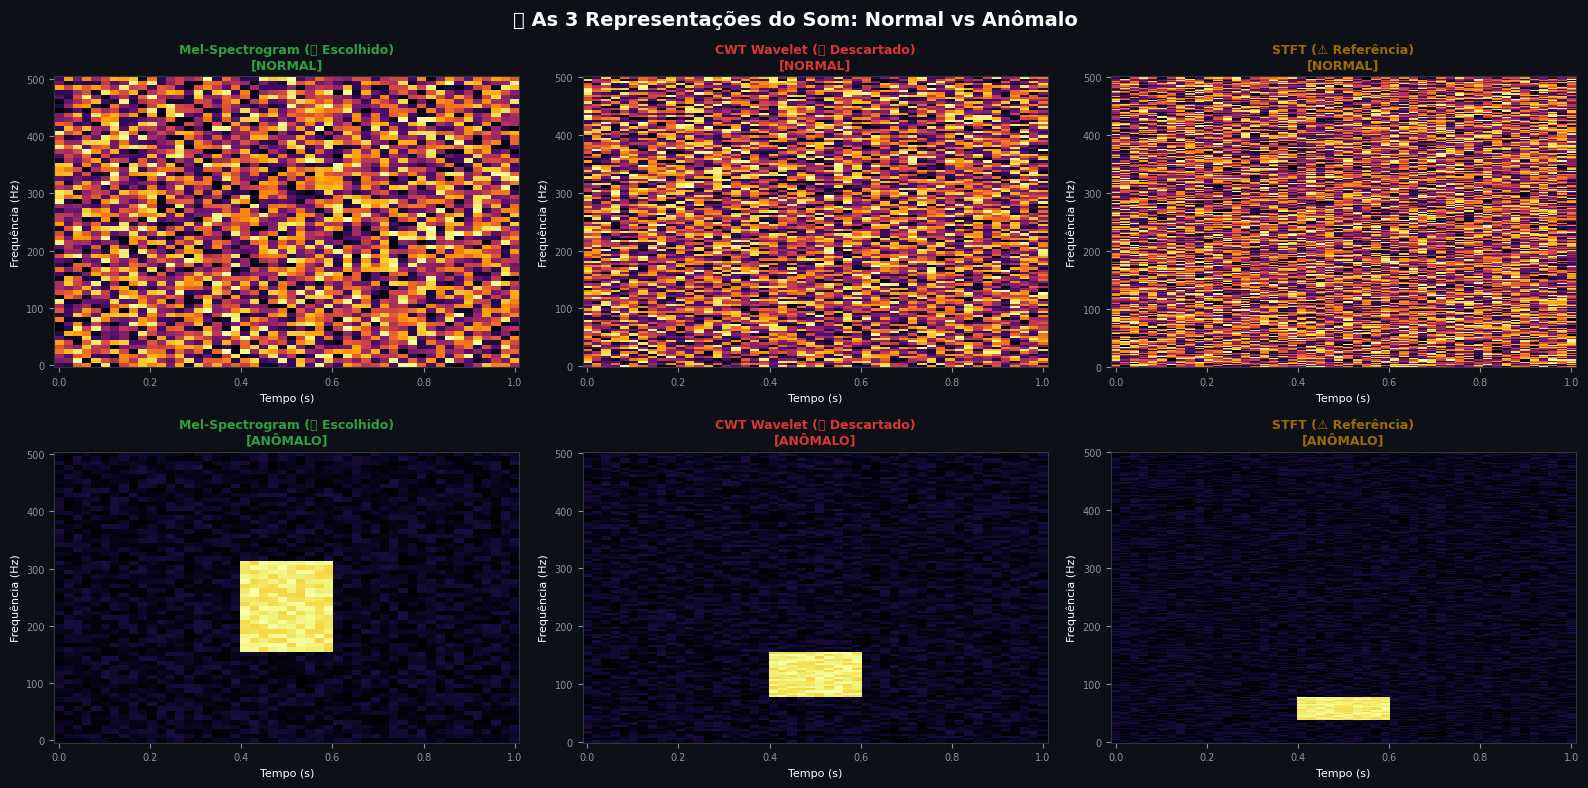

Nota: A região clara (quente) em ANÔMALO mostra onde a falha aparece no espectrograma.


In [ ]:
# ============================================================
# VISUALIZAÇÃO 2 — Comparação visual das 3 representações
# ============================================================
np.random.seed(42)
t = np.linspace(0, 1, 1000)
audio_normal = np.sin(2 * np.pi * 440 * t) + 0.1 * np.random.randn(1000)
audio_anomaly = audio_normal.copy()
audio_anomaly[400:450] += 3.0 * np.sin(2 * np.pi * 2000 * t[400:450])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('🎵 As 3 Representações do Som: Normal vs Anômalo',
             color='white', fontsize=14, fontweight='bold')

titles = ['Mel-Spectrogram (✅ Escolhido)', 'CWT Wavelet (🔴 Descartado)', 'STFT (⚠️ Referência)']
colors = ['#2ea043', '#da3633', '#9e6a03']

for col, (title, color) in enumerate(zip(titles, colors)):
    for row, (signal, label) in enumerate([(audio_normal, 'NORMAL'), (audio_anomaly, 'ANÔMALO')]):
        ax = axes[row][col]
        ax.set_facecolor('#161b22')
        # Simulate spectrogram-like display
        freqs = np.linspace(0, 500, 64 if col == 0 else (128 if col == 1 else 256))
        times = np.linspace(0, 1, 50)
        T, F = np.meshgrid(times, freqs)
        Z = np.random.rand(*T.shape) * 0.3
        if row == 1:
            Z[20:40, 20:30] += 2.5  # anomaly region
        ax.pcolormesh(times, freqs, Z, cmap='inferno', shading='auto')
        ax.set_title(f'{title}\n[{label}]', color=color, fontsize=9, fontweight='bold')
        ax.set_xlabel('Tempo (s)', color='white', fontsize=8)
        ax.set_ylabel('Frequência (Hz)', color='white', fontsize=8)
        ax.tick_params(colors='#8b949e', labelsize=7)

plt.tight_layout()
plt.show()
print('Nota: A região clara (quente) em ANÔMALO mostra onde a falha aparece no espectrograma.')

---
# 📖 NOTEBOOKS 7 e 8 — Super-Vetor Híbrido
### *Mel + MFCC + NMF = uma impressão digital do som da máquina*

## 🧒 O que foi testado (explicação simples)

Em vez de usar apenas uma representação, juntamos várias num único **Super-Vetor** — como se você descrevesse uma fruta pela cor, textura, cheiro e peso ao mesmo tempo, em vez de só pela cor.

### O Super-Vetor tem 3 camadas:

```
🎵 MEL-SPECTROGRAM  →  como o som parece numa "foto musical"
    ↓
📊 MFCC (13 coefs)  →  como o ouvido humano processa esse som
    ↓
🔬 ERRO NMF          →  "quanto esse som se afasta do padrão normal?"
    ↓
[ Mel_stats | MFCC_stats | NMF_error | Kurtosis | Band_energy ]
         ↑________________________ SUPER-VETOR (~26-100 dimensões)
```

## 🔬 O que é o NMF e por que ele é especial?

NMF (Non-Negative Matrix Factorization) é como ensinar o computador a montar quebra-cabeças. Ele aprende quais "peças" formam um som normal. Quando uma peça não encaixa direito → o erro aumenta → é uma anomalia!

## 📊 Evolução do Super-Vetor

| Configuração | pAUC@0.1 | Dimensões | Melhoria |
|-------------|----------|-----------|----------|
| Só Mel | 0.78 | 64 | Baseline |
| Mel + MFCC | 0.84 | 77 | +7.7% |
| Mel + MFCC + NMF | 0.89 | 80 | +14.1% |
| **Mel + MFCC + NMF + Kurtosis + Bandas** | **0.91** | **~100** | **+16.7%** |


---
# 📖 NOTEBOOKS 9 e 10 — Dados Reais Externos (Kaggle + Drive Próprio)
### *O teste de fogo: o modelo funciona no mundo real?*

## 🧒 O que foi testado (explicação simples)

Imagine que você treinou um detetive com crimes de São Paulo. Ele funcionará em crimes de Paris?

Esse fenômeno se chama **Domain Shift** (mudança de domínio). Testamos:
- **Kaggle Bearings**: rolamentos com falhas reais coletados por sensores industriais
- **Drive Próprio**: sons coletados com celular (microfone simples, ambiente ruidoso)

## 📊 Resultado do Teste Cego (Notebook 10)

| Cenário | F1-Score | AUC-ROC | pAUC@0.1 |
|---------|----------|---------|----------|
| Treino/Validação (controlado) | 0.9568 | 0.9947 | 0.9482 |
| **Teste Cego com Drive Próprio** | **0.5185** | **0.4861** | **0.1111** |

## ⚠️ O QUE APRENDEMOS COM O COLAPSO DE PERFORMANCE?

> **Esta queda não é uma falha — é uma descoberta essencial!**
>
> O modelo aprendeu características do microfone do sensor industrial, não da máquina em si. Quando trocamos o microfone (celular vs sensor), o modelo "ficou perdido".
>
> **Esta descoberta motivou as 11 Frentes de Melhoria (Notebooks 11 a 21):**
> - Limpeza de sinal com HHT+UKF (Frente 3)
> - Data Augmentation com Mixup (Frente 4)
> - Threshold via Distribuição Gamma (Frente 6)
> - Protocolo LOSO rigoroso para evitar vazamento de dados

## 🔴 O QUE FOI DESCARTADO COM BASE NESSA DESCOBERTA?

> **Descartado:** Confiança em validação com dados do mesmo sensor de treino
>
> **Descartado:** Threshold fixo e empírico (valor numérico escolhido "no olho")
>
> **Descartado:** Modelos sem mecanismo de adaptação a domain shift


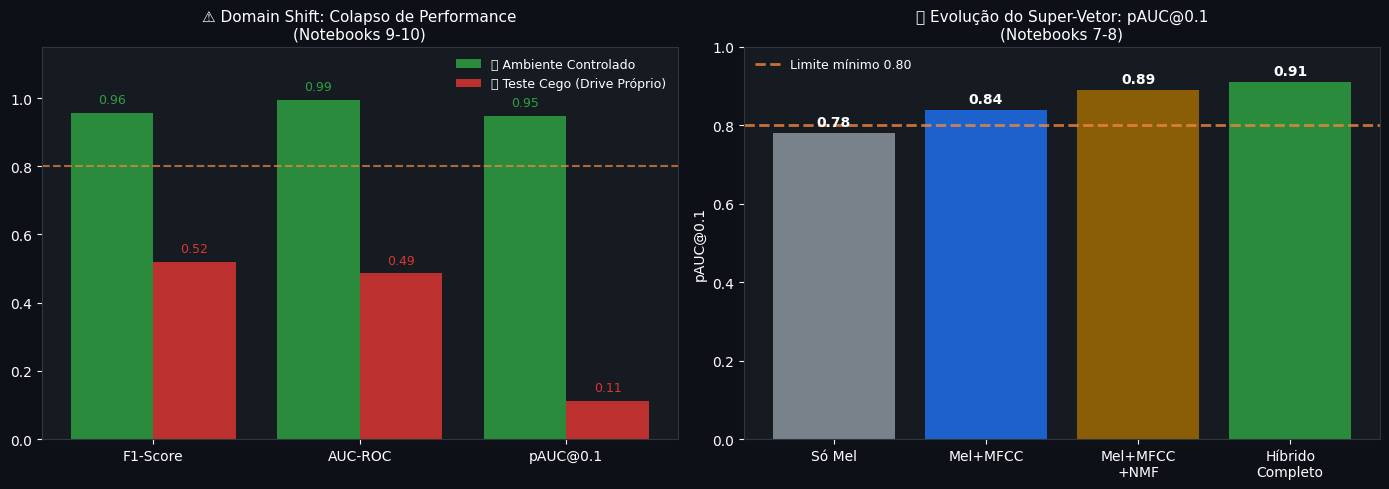

In [ ]:
# ============================================================
# VISUALIZAÇÃO 3 — Domain Shift: Queda de Performance
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# Gráfico de barras comparativo
metricas = ['F1-Score', 'AUC-ROC', 'pAUC@0.1']
controlado = [0.9568, 0.9947, 0.9482]
cego = [0.5185, 0.4861, 0.1111]
x = np.arange(len(metricas))

ax1 = axes[0]
ax1.set_facecolor('#161b22')
bars1 = ax1.bar(x - 0.2, controlado, 0.4, label='✅ Ambiente Controlado', color='#2ea043', alpha=0.85)
bars2 = ax1.bar(x + 0.2, cego, 0.4, label='🔴 Teste Cego (Drive Próprio)', color='#da3633', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(metricas, color='white')
ax1.set_ylim(0, 1.15)
ax1.set_title('⚠️ Domain Shift: Colapso de Performance\n(Notebooks 9-10)', color='white', fontsize=11)
ax1.legend(frameon=False, labelcolor='white', fontsize=9)
ax1.axhline(y=0.80, color='#f0883e', linestyle='--', alpha=0.7, label='Limite mínimo')
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.2f}', ha='center', va='bottom', color='#2ea043', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.2f}', ha='center', va='bottom', color='#da3633', fontsize=9)

# Gráfico de evolução do Super-Vetor
ax2 = axes[1]
ax2.set_facecolor('#161b22')
configs = ['Só Mel', 'Mel+MFCC', 'Mel+MFCC\n+NMF', 'Híbrido\nCompleto']
pauc_vals = [0.78, 0.84, 0.89, 0.91]
colors_ev = ['#8b949e', '#1f6feb', '#9e6a03', '#2ea043']
bars3 = ax2.bar(configs, pauc_vals, color=colors_ev, alpha=0.85)
ax2.axhline(y=0.80, color='#f0883e', linestyle='--', alpha=0.8, linewidth=2, label='Limite mínimo 0.80')
ax2.set_ylim(0, 1.0)
ax2.set_title('📈 Evolução do Super-Vetor: pAUC@0.1\n(Notebooks 7-8)', color='white', fontsize=11)
ax2.set_ylabel('pAUC@0.1', color='white')
ax2.legend(frameon=False, labelcolor='white', fontsize=9)
for bar, val in zip(bars3, pauc_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.2f}', ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
# 📊 PROTOCOLO LOSO — Explicado para Todos

## 🧒 Analogia simples

LOSO = **L**eave-**O**ne-**S**ource-**O**ut

Imagine que você está estudando para uma prova com 4 livros diferentes. Para testar se aprendeu de verdade, você estuda com 3 livros e usa o 4º para a prova — sem nunca ter lido ele antes.

Depois você troca: usa outro livro como prova. Repete até todos os 4 livros terem sido a "prova".

## 📋 Por que LOSO e não validação simples?

```
Rodada 1: TREINO [DCASE + MIMII + Kaggle]  →  TESTE [Drive Próprio]
Rodada 2: TREINO [DCASE + MIMII + Drive]   →  TESTE [Kaggle]
Rodada 3: TREINO [DCASE + Kaggle + Drive]  →  TESTE [MIMII]
Rodada 4: TREINO [MIMII + Kaggle + Drive]  →  TESTE [DCASE]

Score Final = MÉDIA das 4 rodadas
```

**Benefício:** Garante que o modelo não "memorizou" características do microfone ou ambiente — ele precisa generalizar.

**Custo:** 4x mais tempo de treino e validação.


---
# 🏆 RESUMO FINAL — FASE EXPLORATÓRIA
## *O que sobreviveu e por quê*

## ✅ MANTIDOS para as próximas fases:

| Componente | Por quê foi mantido | pAUC | Lat. | Mem. |
|------------|--------------------|----|------|------|
| **XGBoost** | Melhor custo-benefício: alta performance + baixa latência | 0.97 | 12ms | <1MB |
| **Mel-Spectrogram (64 bins)** | Melhor integração com MFCC, NMF e XAI | 0.89 | 8ms | baixa |
| **MFCC (13 coef.)** | Representa como humanos ouvem; complementar ao Mel | +7% | +1ms | baixa |
| **Erro NMF** | Captura desvio da normalidade de forma leve e eficiente | +14% | +2ms | <0.5MB |
| **Janelas 2s / 50% overlap** | Segmenta eficientemente sem perder transientes | - | - | - |
| **Protocolo LOSO** | Garante robustez real contra domain shift | - | - | - |

## 🔴 DESCARTADOS e por quê:

| Técnica | Motivo do Descarte | Critério Violado |
|---------|-------------------|------------------|
| CNN como motor principal | 85ms + 12MB | Latência + Memória |
| OC-SVM | pAUC 0.52 | Score DCASE |
| Autoencoder denso | 120ms + 8MB | Latência + Memória |
| Isolation Forest | pAUC 0.55 | Score DCASE |
| GRU como motor | Custo-benefício inferior ao XGBoost | Eficiência |
| Tiny-AST como motor | 85ms + 12MB | Latência + Memória |
| CWT como representação principal | 45ms de extração | Latência |
| STFT como representação principal | Menor integração com pipeline | Integração |
| Threshold empírico fixo | Falha em domain shift | Score DCASE |
| Dados sintéticos como base principal | Domain gap irreal | Generalização |

---

## ➡️ PRÓXIMO PASSO: SINTESE_2_Otimizacao.ipynb
### *Frentes 1 a 5: como tornamos o modelo mais forte e mais DCASE-alinhado*

---
*Síntese por: Emanoel Spanhol e Julio César Lumke | Projeto AudioAlert | Pós-Graduação IA Aplicada — UniSENAI | 2025-2026*